# Combined Experiments 009 + 010: Comprehensive Analysis
## Unified Post-Normalization Parameter Space Exploration

**Analysis Date**: October 21, 2025  
**Total Experiments**: 42 (21 from Exp 009 + 21 from Exp 010)  
**Dataset**: 15K workers, 20K tasks per experiment  
**Key Innovation**: Score normalization + High-resolution Pareto mapping

---

## Executive Summary

This notebook presents a **unified analysis** of two complementary parameter sweep experiments:

- **Experiment 009**: Comprehensive exploration (8 groups, broad parameter ranges)
- **Experiment 010**: High-resolution Pareto frontier mapping (λ₁ × λ₃ grid)

Together, these provide both **breadth** and **depth** in understanding fairness-efficiency trade-offs.

### Key Questions Addressed
1. What is the optimal balance between fairness (λ₁), starvation (λ₂), and utility (λ₃)?
2. Has score normalization resolved the worker idle time paradox?
3. Which parameters have the strongest impact on system performance?
4. What are the practical boundaries of the Pareto frontier?

---

## 🔧 Setup & Data Loading

In [42]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

# Define colors
COLORS = {
    'greedy': '#FF6B6B',
    'exp_009': '#4ECDC4',
    'exp_010': '#45B7D1'
}

print("Libraries imported successfully")

Libraries imported successfully


In [43]:
# Load data
df = pd.read_csv('data/experiment_009+010_combined_results.csv')

print(f"Loaded {len(df)} experiments")
print(f"Shape: {df.shape}")
print(f"\nStrategy breakdown:")
print(df['strategy'].value_counts())
print(f"\nSource breakdown:")
print(df['source_experiment'].value_counts())

Loaded 42 experiments
Shape: (42, 26)

Strategy breakdown:
strategy
composite    41
greedy        1
Name: count, dtype: int64

Source breakdown:
source_experiment
exp_009    21
exp_010    21
Name: count, dtype: int64


In [44]:
# Preview
display(df.head())
display(df.describe())

,experiment_id,source_experiment,original_experiment_id,group,name,description,strategy,fairness_weight,starvation_weight,utility_weight,...,mean_task_wait_time_min,mean_pickup_distance_km,total_travel_km,peak_backlog,duration_seconds,timestamp,mean_worker_idle_time_min,empty_km_ratio,ewma_cv,max_wait_time
0,1,exp_009,22,E,Balanced_L1_0.2_L3_1.2,"L1=0.2, L2=0.8, L3=1.2, Threshold=0.5",composite,0.2,0.8,1.2,...,2.627917,1.309930,167792.101008,20,1805.813675,2025-10-20T09:18:39.454372,NaN,NaN,NaN,NaN
1,2,exp_009,23,E,Balanced_L1_0.2_L3_1.6,"L1=0.2, L2=0.8, L3=1.6, Threshold=0.5",composite,0.2,0.8,1.6,...,2.593261,1.292508,167439.370744,21,1705.055827,2025-10-20T09:47:04.514825,NaN,NaN,NaN,NaN
2,3,exp_009,24,E,Balanced_L1_0.2_L3_2.0,"L1=0.2, L2=0.8, L3=2.0, Threshold=0.5",composite,0.2,0.8,2.0,...,2.580856,1.287414,167408.766817,20,1679.699177,2025-10-20T10:15:04.215630,NaN,NaN,NaN,NaN
3,4,exp_009,25,E,Balanced_L1_0.4_L3_1.2,"L1=0.4, L2=0.8, L3=1.2, Threshold=0.5",composite,0.4,0.8,1.2,...,2.604906,1.299447,167686.163201,18,1612.705612,2025-10-20T10:41:56.922992,NaN,NaN,NaN,NaN
4,5,exp_009,26,E,Balanced_L1_0.4_L3_1.6,"L1=0.4, L2=0.8, L3=1.6, Threshold=0.5",composite,0.4,0.8,1.6,...,2.598354,1.296185,167593.896317,19,1617.589357,2025-10-20T11:08:54.513924,NaN,NaN,NaN,NaN


,experiment_id,original_experiment_id,fairness_weight,starvation_weight,utility_weight,soft_threshold,gamma,completed_tasks,task_assignment_ratio,jains_fairness_index,mean_task_wait_time_min,mean_pickup_distance_km,total_travel_km,peak_backlog,duration_seconds,mean_worker_idle_time_min,empty_km_ratio,ewma_cv,max_wait_time
count,42.000000,42.000000,41.000000,41.000000,41.000000,41.0,41.0,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,0.0,21.0,21.000000,21.0
mean,21.500000,21.500000,2.390244,0.697561,1.214634,0.5,0.5,17248.190476,0.862410,0.281897,2.779132,1.386277,169157.223698,19.166667,1635.161525,NaN,0.0,1.898160,0.0
std,12.267844,12.267844,1.778174,0.292821,0.633467,0.0,0.0,1.580955,0.000079,0.011180,0.211502,0.105572,1850.547789,1.480222,105.036117,NaN,0.0,0.657961,0.0
min,1.000000,1.000000,0.100000,0.500000,0.100000,0.5,0.5,17244.000000,0.862200,0.262708,1.901466,0.948998,161605.456110,16.000000,1522.898743,NaN,0.0,0.465858,0.0
25%,11.250000,11.250000,0.600000,0.500000,0.500000,0.5,0.5,17247.000000,0.862350,0.267645,2.615465,1.304387,167733.180178,18.000000,1557.663470,NaN,0.0,1.421892,0.0
50%,21.500000,21.500000,2.500000,0.500000,1.200000,0.5,0.5,17248.000000,0.862400,0.287436,2.804411,1.398729,169333.440906,19.000000,1625.364624,NaN,0.0,1.903372,0.0
75%,31.750000,31.750000,4.000000,0.800000,1.600000,0.5,0.5,17249.000000,0.862450,0.290863,2.944795,1.469187,170621.905315,20.000000,1670.219619,NaN,0.0,2.535779,0.0
max,42.000000,42.000000,5.000000,2.000000,2.000000,0.5,0.5,17251.000000,0.862550,0.295331,3.088662,1.541178,171908.762907,23.000000,2030.316442,NaN,0.0,2.815995,0.0


In [45]:
# Separate strategies
df_greedy = df[df['strategy'] == 'greedy'].copy()
df_composite = df[df['strategy'] == 'composite'].copy()

print(f"Greedy: {len(df_greedy)}")
print(f"Composite: {len(df_composite)}")

Greedy: 1
Composite: 41


## 📈 Summary Statistics

In [46]:
# Group statistics
metrics = ['jains_fairness_index', 'mean_task_wait_time_min', 'task_assignment_ratio', 
           'mean_pickup_distance_km', 'peak_backlog']

group_stats = df_composite.groupby('source_experiment')[metrics].agg(['mean', 'std', 'min', 'max'])
print("Statistics by Source:")
display(group_stats.round(4))

Statistics by Source:


jains_fairness_index                          \
                                  mean     std     min     max   
source_experiment                                                
exp_009                         0.2764  0.0123  0.2634  0.2939   
exp_010                         0.2886  0.0033  0.2830  0.2953   

                  mean_task_wait_time_min                          \
                                     mean     std     min     max   
source_experiment                                                   
exp_009                             2.741  0.1918  2.5633  3.0887   
exp_010                             2.863  0.0909  2.7048  2.9684   

                  task_assignment_ratio                          \
                                   mean     std     min     max   
source_experiment                                                 
exp_009                          0.8624  0.0001  0.8622  0.8626   
exp_010                          0.8624  0.0001  0.8624  0.8626   

                  mean_pickup_distance_km                          \
                                     mean     std     min     max   
source_experiment                                                   
exp_009                            1.3673  0.0959  1.2786  1.5412   
exp_010                            1.4280  0.0456  1.3485  1.4811   

                  peak_backlog                  
                          mean     std min max  
source_experiment                               
exp_009                19.5238  1.5690  17  23  
exp_010                18.9000  1.2937  16  21

In [47]:
# Overall statistics
print("Overall Composite Performance:")
for metric in ['jains_fairness_index', 'mean_task_wait_time_min', 'task_assignment_ratio']:
    print(f"\n{metric}:")
    print(f"  Range: {df_composite[metric].min():.4f} - {df_composite[metric].max():.4f}")
    print(f"  Mean: {df_composite[metric].mean():.4f} ± {df_composite[metric].std():.4f}")

Overall Composite Performance:

jains_fairness_index:
  Range: 0.2634 - 0.2953
  Mean: 0.2824 ± 0.0109

mean_task_wait_time_min:
  Range: 2.5633 - 3.0887
  Mean: 2.8005 ± 0.1616

task_assignment_ratio:
  Range: 0.8622 - 0.8626
  Mean: 0.8624 ± 0.0001


## 🔑 Identify Key Profiles

In [48]:
# Key profiles
greedy_profile = df_greedy.iloc[0] if len(df_greedy) > 0 else None
top_fairness = df_composite.nlargest(1, 'jains_fairness_index').iloc[0]
top_efficiency = df_composite.nsmallest(1, 'mean_task_wait_time_min').iloc[0]

# Sweet spot - balanced
df_composite['norm_jfi'] = (df_composite['jains_fairness_index'] - df_composite['jains_fairness_index'].min()) / \
                            (df_composite['jains_fairness_index'].max() - df_composite['jains_fairness_index'].min())
df_composite['norm_inv_wait'] = 1 - ((df_composite['mean_task_wait_time_min'] - df_composite['mean_task_wait_time_min'].min()) / \
                                     (df_composite['mean_task_wait_time_min'].max() - df_composite['mean_task_wait_time_min'].min()))
df_composite['balance_score'] = df_composite['norm_jfi'] + df_composite['norm_inv_wait']
sweet_spot = df_composite.nlargest(1, 'balance_score').iloc[0]

print("KEY PROFILES:")
print("=" * 80)
if greedy_profile is not None:
    print(f"\n1️GREEDY: JFI={greedy_profile['jains_fairness_index']:.4f}, Wait={greedy_profile['mean_task_wait_time_min']:.2f}min")
print(f"\n2️TOP FAIRNESS: λ₁={top_fairness['fairness_weight']:.1f}, λ₃={top_fairness['utility_weight']:.1f}")
print(f"   JFI={top_fairness['jains_fairness_index']:.4f}, Wait={top_fairness['mean_task_wait_time_min']:.2f}min")
print(f"\n3️TOP EFFICIENCY: λ₁={top_efficiency['fairness_weight']:.1f}, λ₃={top_efficiency['utility_weight']:.1f}")
print(f"   JFI={top_efficiency['jains_fairness_index']:.4f}, Wait={top_efficiency['mean_task_wait_time_min']:.2f}min")
print(f"\n4️SWEET SPOT: λ₁={sweet_spot['fairness_weight']:.1f}, λ₃={sweet_spot['utility_weight']:.1f}")
print(f"   JFI={sweet_spot['jains_fairness_index']:.4f}, Wait={sweet_spot['mean_task_wait_time_min']:.2f}min")

KEY PROFILES:

1️GREEDY: JFI=0.2627, Wait=1.90min

2️TOP FAIRNESS: λ₁=2.5, λ₃=0.5
   JFI=0.2953, Wait=2.96min

3️TOP EFFICIENCY: λ₁=0.6, λ₃=2.0
   JFI=0.2675, Wait=2.56min

4️SWEET SPOT: λ₁=2.5, λ₃=2.0
   JFI=0.2895, Wait=2.70min


---\n\n# ⚖️ SECTION 1: Trade-off & Pareto Analysis

## Plot 2: Pareto Frontier

In [49]:
# Compute Pareto frontier
def is_pareto_efficient(costs):
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient

# Maximize JFI, minimize Wait Time → minimize (-JFI, Wait)
costs = np.column_stack([
    -df_composite['jains_fairness_index'].values,
    df_composite['mean_task_wait_time_min'].values
])
pareto_mask = is_pareto_efficient(costs)
df_composite['is_pareto'] = pareto_mask

print(f"Found {pareto_mask.sum()} Pareto-efficient configurations")

Found 7 Pareto-efficient configurations


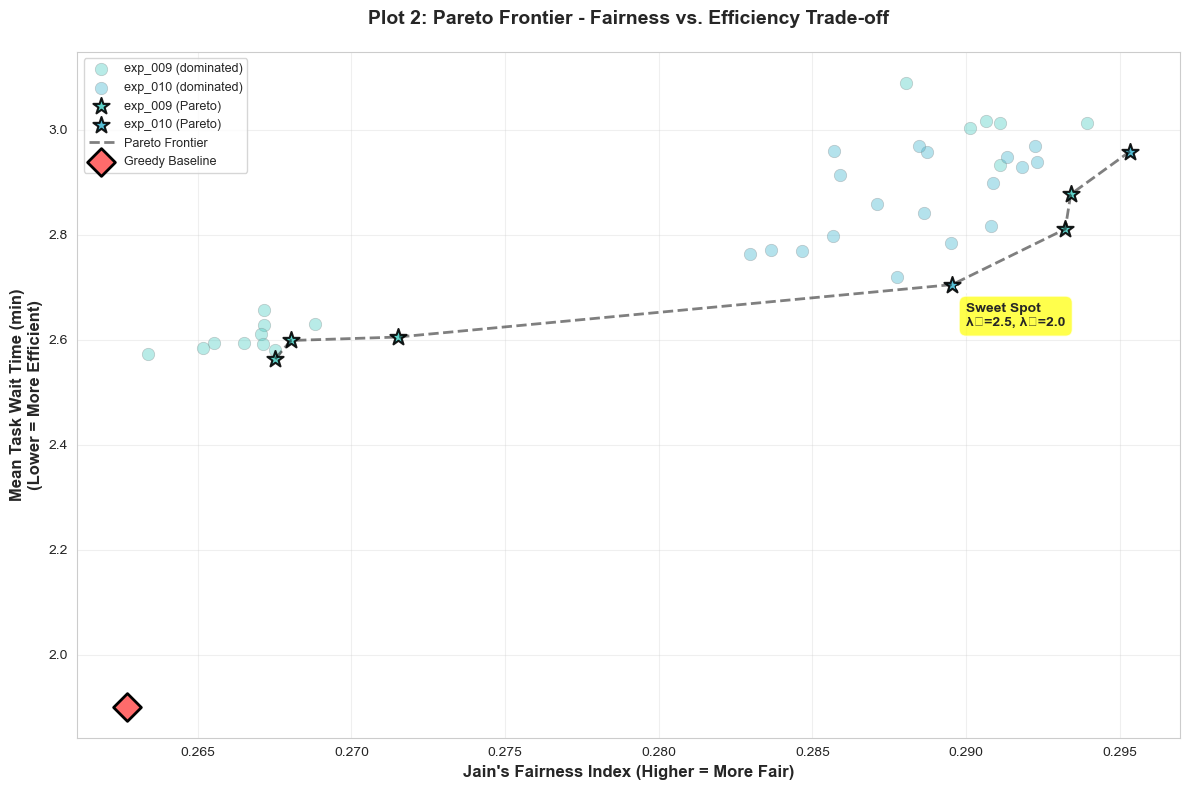


Pareto configurations (7):


,name,fairness_weight,utility_weight,jains_fairness_index,mean_task_wait_time_min
22,ParetoSweep_L1_2.5_L3_0.5,2.5,0.5,0.295331,2.958164
11,HighFairness_L3_1.5,5.0,1.5,0.293406,2.876775
12,HighFairness_L3_2.0,5.0,2.0,0.293229,2.810587
25,ParetoSweep_L1_2.5_L3_2.0,2.5,2.0,0.289548,2.704766
3,Balanced_L1_0.4_L3_1.2,0.4,1.2,0.271503,2.604906
4,Balanced_L1_0.4_L3_1.6,0.4,1.6,0.268027,2.598354
8,Balanced_L1_0.6_L3_2.0,0.6,2.0,0.267518,2.563295


In [50]:
# Plot Pareto Frontier
fig, ax = plt.subplots(figsize=(12, 8))

# Non-Pareto points
for source in ['exp_009', 'exp_010']:
    df_src = df_composite[(df_composite['source_experiment'] == source) & (~df_composite['is_pareto'])]
    ax.scatter(df_src['jains_fairness_index'], df_src['mean_task_wait_time_min'],
               s=80, alpha=0.4, c=COLORS[source], label=f'{source} (dominated)',
               edgecolors='gray', linewidth=0.5)

# Pareto points
for source in ['exp_009', 'exp_010']:
    df_src = df_composite[(df_composite['source_experiment'] == source) & (df_composite['is_pareto'])]
    ax.scatter(df_src['jains_fairness_index'], df_src['mean_task_wait_time_min'],
               s=150, alpha=0.9, c=COLORS[source], marker='*',
               label=f'{source} (Pareto)', edgecolors='black', linewidth=1.5)

# Pareto line
pareto_pts = df_composite[df_composite['is_pareto']].sort_values('jains_fairness_index')
ax.plot(pareto_pts['jains_fairness_index'], pareto_pts['mean_task_wait_time_min'],
        'k--', linewidth=2, alpha=0.5, label='Pareto Frontier')

# Greedy
if greedy_profile is not None:
    ax.scatter([greedy_profile['jains_fairness_index']], [greedy_profile['mean_task_wait_time_min']],
               s=200, c=COLORS['greedy'], marker='D', edgecolors='black', linewidth=2, 
               label='Greedy Baseline', zorder=5)

# Annotate sweet spot
ax.annotate(f"Sweet Spot\nλ₁={sweet_spot['fairness_weight']:.1f}, λ₃={sweet_spot['utility_weight']:.1f}",
            xy=(sweet_spot['jains_fairness_index'], sweet_spot['mean_task_wait_time_min']),
            xytext=(10, -30), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2), fontsize=10, fontweight='bold')

ax.set_xlabel('Jain\'s Fairness Index (Higher = More Fair)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Task Wait Time (min)\n(Lower = More Efficient)', fontsize=12, fontweight='bold')
ax.set_title('Plot 2: Pareto Frontier - Fairness vs. Efficiency Trade-off', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot_02_pareto_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPareto configurations ({pareto_mask.sum()}):")
pareto_configs = df_composite[df_composite['is_pareto']][['name', 'fairness_weight', 'utility_weight', 
                                                            'jains_fairness_index', 'mean_task_wait_time_min']]
display(pareto_configs.sort_values('jains_fairness_index', ascending=False))

### Key Takeaways - Plot 2\n\n*To be filled after analysis*

## Plot 6: Efficiency Frontier - Distance vs. Wait Time

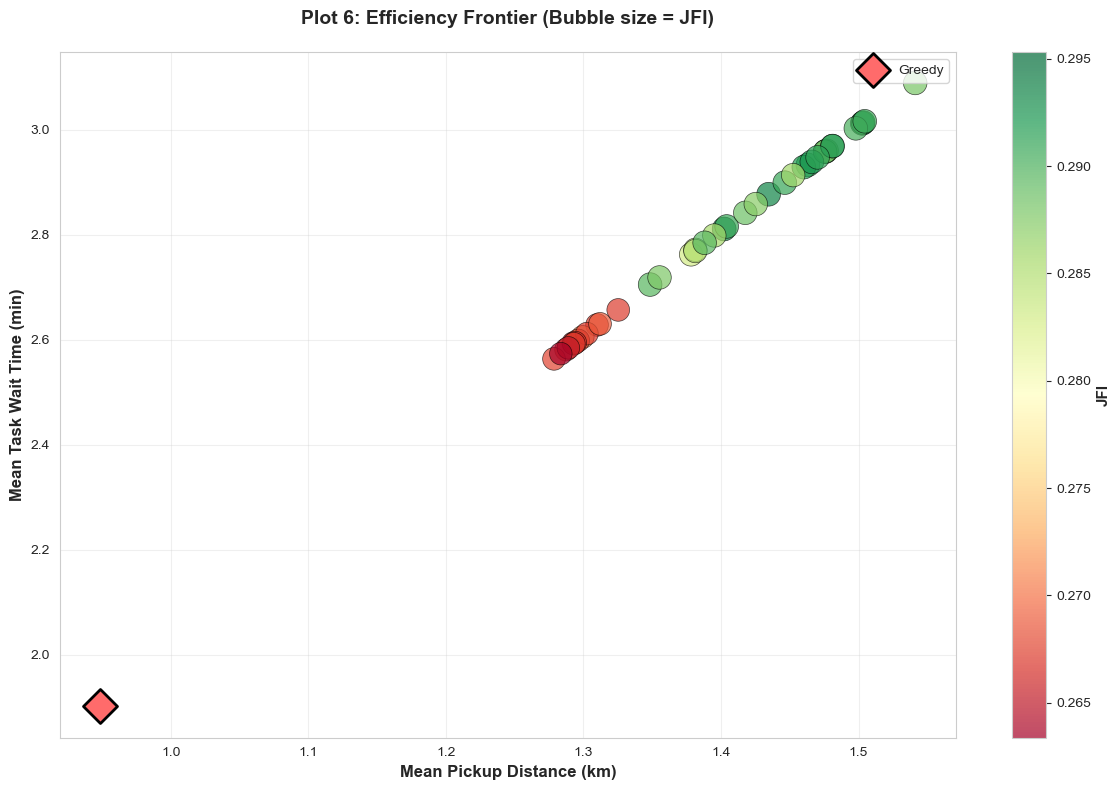


Correlation (Distance vs Wait): r=1.0000, p=6.5711e-91


In [51]:
# Plot 6
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df_composite['mean_pickup_distance_km'],
                     df_composite['mean_task_wait_time_min'],
                     s=df_composite['jains_fairness_index'] * 1000,
                     c=df_composite['jains_fairness_index'],
                     cmap='RdYlGn', alpha=0.7,
                     edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('JFI', fontsize=11, fontweight='bold')

if greedy_profile is not None:
    ax.scatter([greedy_profile['mean_pickup_distance_km']], [greedy_profile['mean_task_wait_time_min']],
               s=300, c=COLORS['greedy'], marker='D', edgecolors='black', linewidth=2, 
               label='Greedy', zorder=5)

ax.set_xlabel('Mean Pickup Distance (km)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Task Wait Time (min)', fontsize=12, fontweight='bold')
ax.set_title('Plot 6: Efficiency Frontier (Bubble size = JFI)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot_06_efficiency_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

corr, p = pearsonr(df_composite['mean_pickup_distance_km'], df_composite['mean_task_wait_time_min'])
print(f"\nCorrelation (Distance vs Wait): r={corr:.4f}, p={p:.4e}")

### Key Takeaways - Plot 6\n\n*To be filled after analysis*

---\n\n# 🎛️ SECTION 2: Parameter Space Exploration

## Plot 1: Parameter Heatmap - λ₁ vs. λ₃

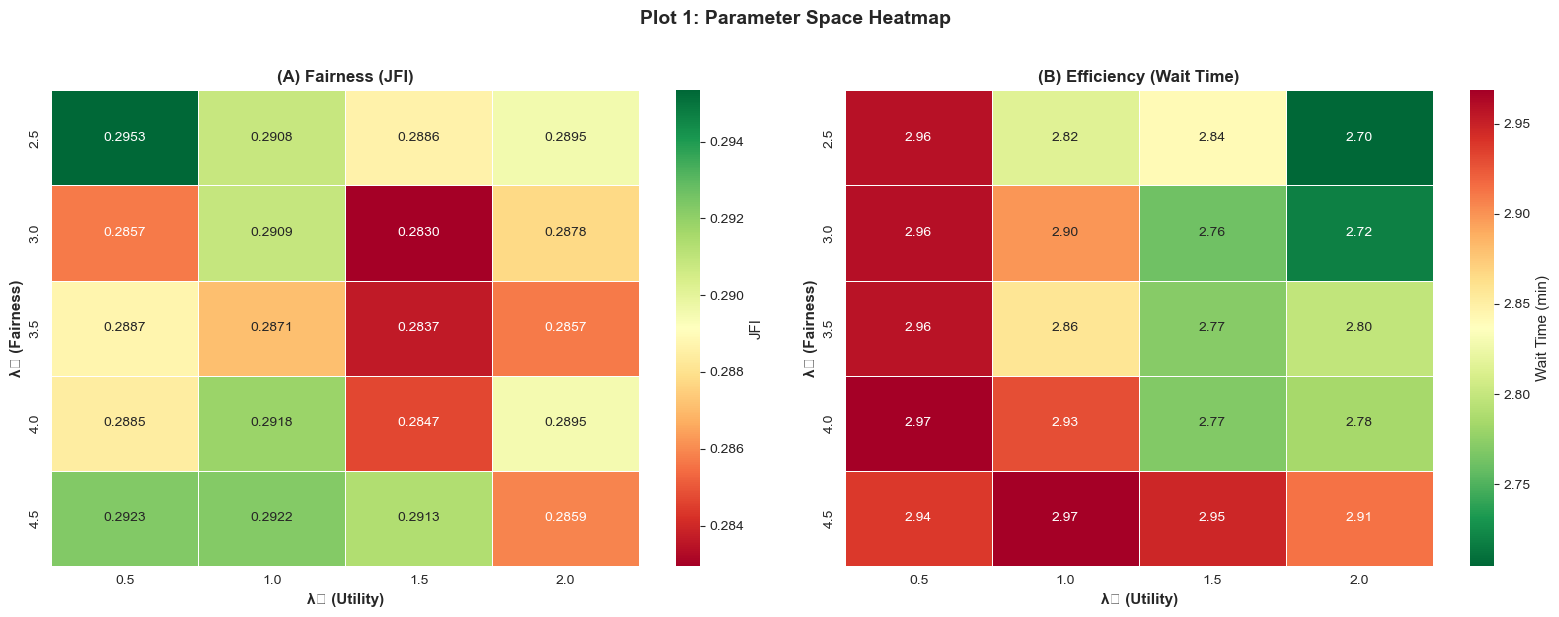

In [52]:
# Plot 1: Parameter Heatmap (using Exp 010 high-resolution grid)
df_grid = df_composite[df_composite['source_experiment'] == 'exp_010'].copy()

if len(df_grid) > 5:
    pivot_jfi = df_grid.pivot_table(values='jains_fairness_index', 
                                     index='fairness_weight', columns='utility_weight', aggfunc='mean')
    pivot_wait = df_grid.pivot_table(values='mean_task_wait_time_min',
                                      index='fairness_weight', columns='utility_weight', aggfunc='mean')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(pivot_jfi, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax1, 
                cbar_kws={'label': 'JFI'}, linewidths=0.5)
    ax1.set_xlabel('λ₃ (Utility)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('λ₁ (Fairness)', fontsize=11, fontweight='bold')
    ax1.set_title('(A) Fairness (JFI)', fontsize=12, fontweight='bold')
    
    sns.heatmap(pivot_wait, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax2,
                cbar_kws={'label': 'Wait Time (min)'}, linewidths=0.5)
    ax2.set_xlabel('λ₃ (Utility)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('λ₁ (Fairness)', fontsize=11, fontweight='bold')
    ax2.set_title('(B) Efficiency (Wait Time)', fontsize=12, fontweight='bold')
    
    fig.suptitle('Plot 1: Parameter Space Heatmap', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/plot_01_parameter_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient grid data")

---\n\n# 🎯 SECTION 3: Multi-Metric Comparison

## Plot 3: Spider/Radar Chart - Configuration Profiles

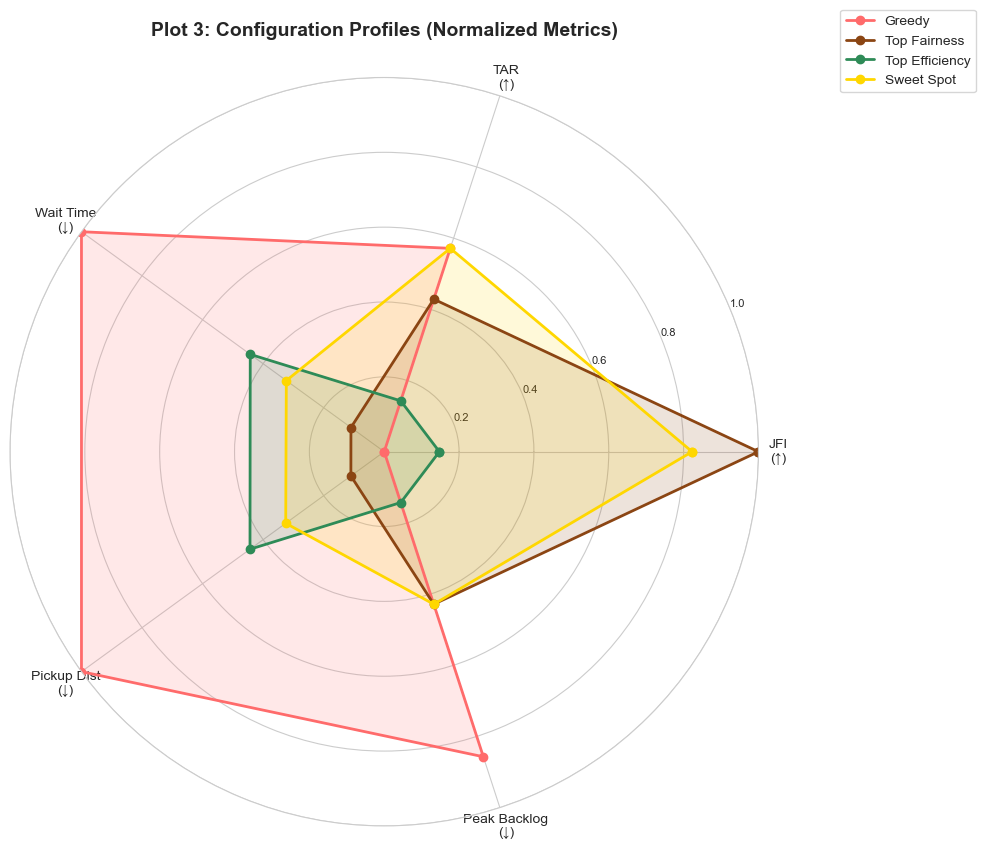

In [53]:
# Plot 3: Radar Chart
from math import pi

# Select key profiles for comparison
profiles = {
    'Greedy': greedy_profile if greedy_profile is not None else None,
    'Top Fairness': top_fairness,
    'Top Efficiency': top_efficiency,
    'Sweet Spot': sweet_spot
}

# Metrics (normalized to 0-1)
metrics_radar = ['jains_fairness_index', 'task_assignment_ratio', 'mean_task_wait_time_min',
                 'mean_pickup_distance_km', 'peak_backlog']
metric_labels = ['JFI\n(↑)', 'TAR\n(↑)', 'Wait Time\n(↓)', 'Pickup Dist\n(↓)', 'Peak Backlog\n(↓)']

# Prepare data
data_normalized = {}
scaler = MinMaxScaler()
for metric in metrics_radar:
    values = df[metric].values.reshape(-1, 1)
    normalized = scaler.fit_transform(values).flatten()
    data_normalized[metric] = dict(zip(df.index, normalized))

# Invert metrics where lower is better
for metric in ['mean_task_wait_time_min', 'mean_pickup_distance_km', 'peak_backlog']:
    for idx in data_normalized[metric]:
        data_normalized[metric][idx] = 1 - data_normalized[metric][idx]

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
angles = [n / len(metrics_radar) * 2 * pi for n in range(len(metrics_radar))]
angles += angles[:1]

colors_profiles = {'Greedy': COLORS['greedy'], 'Top Fairness': '#8B4513', 
                   'Top Efficiency': '#2E8B57', 'Sweet Spot': '#FFD700'}

for profile_name, profile_data in profiles.items():
    if profile_data is not None:
        idx = profile_data.name if hasattr(profile_data, 'name') else profile_data['experiment_id'] - 1
        values = [data_normalized[m].get(idx, 0) for m in metrics_radar]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=profile_name, 
                color=colors_profiles.get(profile_name, 'gray'))
        ax.fill(angles, values, alpha=0.15, color=colors_profiles.get(profile_name, 'gray'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Plot 3: Configuration Profiles (Normalized Metrics)', fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.savefig('figures/plot_03_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

---\n\n# 🧮 SECTION 4: Advanced Statistical Analysis

## Plot 15: Correlation Matrix

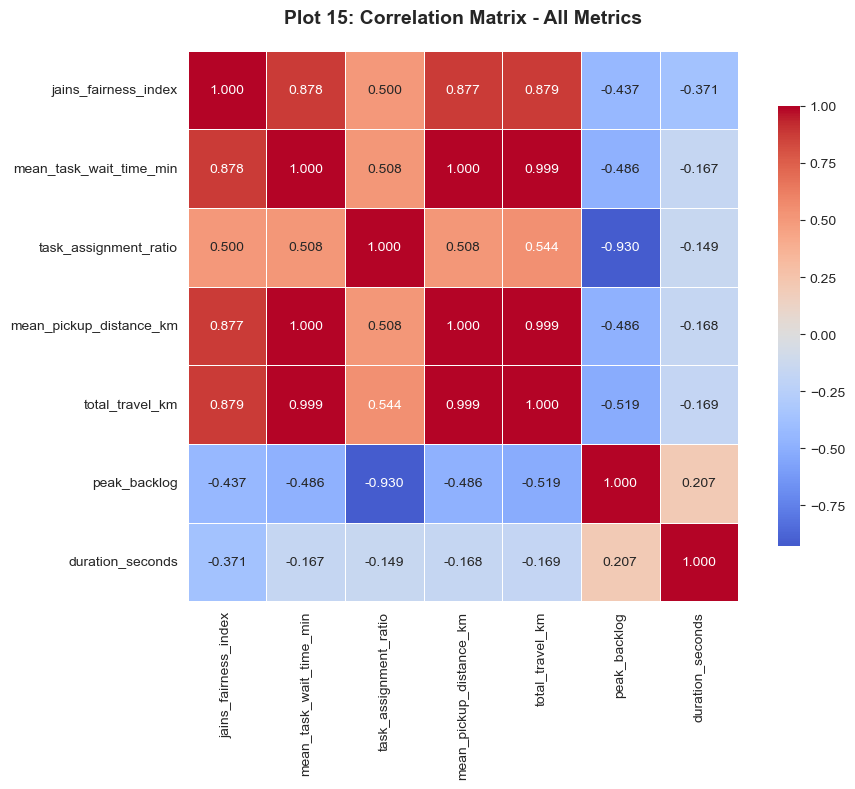


Strong Correlations (|r| > 0.5):
  jains_fairness_index ↔ mean_task_wait_time_min: r = 0.878
  jains_fairness_index ↔ task_assignment_ratio: r = 0.500
  jains_fairness_index ↔ mean_pickup_distance_km: r = 0.877
  jains_fairness_index ↔ total_travel_km: r = 0.879
  mean_task_wait_time_min ↔ task_assignment_ratio: r = 0.508
  mean_task_wait_time_min ↔ mean_pickup_distance_km: r = 1.000
  mean_task_wait_time_min ↔ total_travel_km: r = 0.999
  task_assignment_ratio ↔ mean_pickup_distance_km: r = 0.508
  task_assignment_ratio ↔ total_travel_km: r = 0.544
  task_assignment_ratio ↔ peak_backlog: r = -0.930
  mean_pickup_distance_km ↔ total_travel_km: r = 0.999
  total_travel_km ↔ peak_backlog: r = -0.519


In [54]:
# Plot 15: Correlation Matrix
metrics_corr = ['jains_fairness_index', 'mean_task_wait_time_min', 'task_assignment_ratio',
                'mean_pickup_distance_km', 'total_travel_km', 'peak_backlog', 'duration_seconds']

# Filter to available metrics
metrics_corr = [m for m in metrics_corr if m in df_composite.columns]

corr_matrix = df_composite[metrics_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Plot 15: Correlation Matrix - All Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figures/plot_15_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStrong Correlations (|r| > 0.5):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: r = {corr_matrix.iloc[i, j]:.3f}")

## Plot 16: Principal Component Analysis

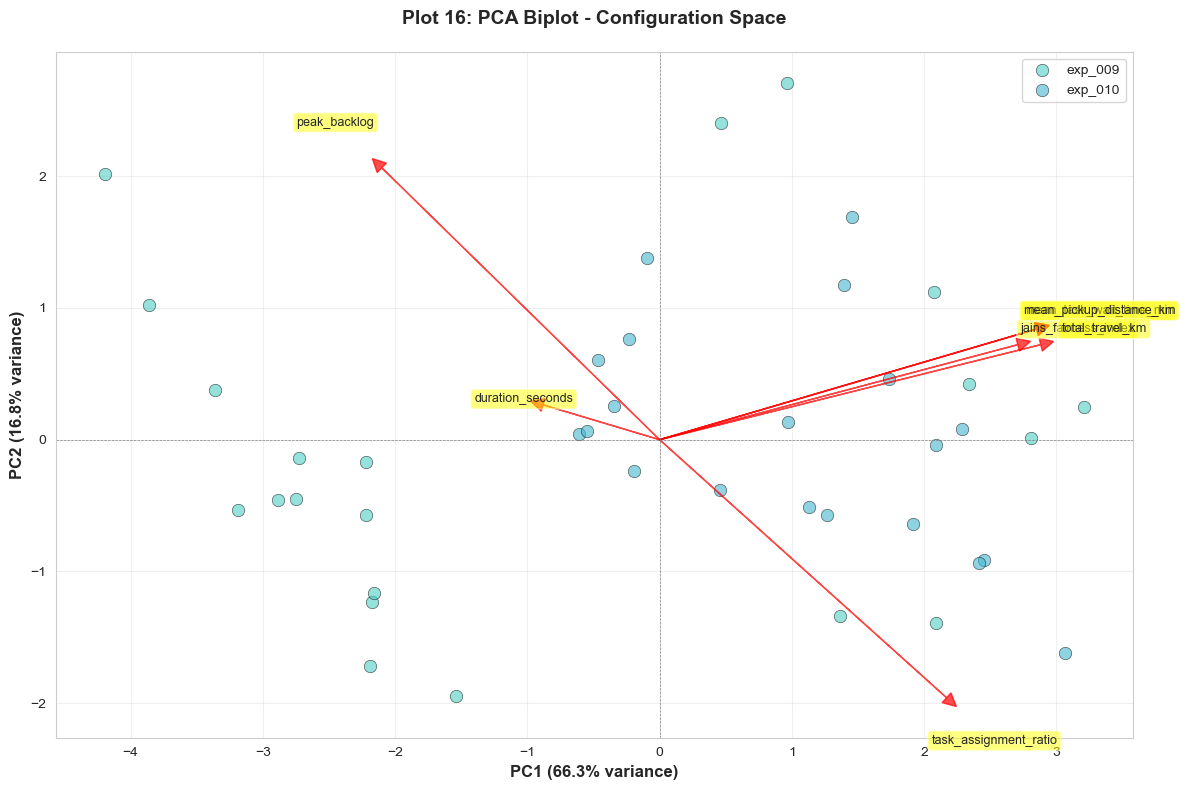


PCA Summary:
  Total variance explained (PC1+PC2): 83.2%
  PC1: 66.3%
  PC2: 16.8%


In [55]:
# Plot 16: PCA Biplot
from sklearn.decomposition import PCA

# Prepare data for PCA (standardize)
X = df_composite[metrics_corr].dropna()
X_standardized = (X - X.mean()) / X.std()

# PCA
pca = PCA(n_components=2)
pc_scores = pca.fit_transform(X_standardized)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
for source in ['exp_009', 'exp_010']:
    mask = df_composite.loc[X.index, 'source_experiment'] == source
    ax.scatter(pc_scores[mask, 0], pc_scores[mask, 1],
               s=80, alpha=0.6, c=COLORS[source], label=source,
               edgecolors='black', linewidth=0.5)

# Loading vectors
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, metric in enumerate(metrics_corr):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
             head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
    ax.text(loadings[i, 0]*3.5, loadings[i, 1]*3.5, metric,
            fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('Plot 16: PCA Biplot - Configuration Space', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('figures/plot_16_pca_biplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPCA Summary:")
print(f"  Total variance explained (PC1+PC2): {pca.explained_variance_ratio_[:2].sum():.1%}")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")

---\n\n# 💡 SECTION 5: Golden Nugget Questions

Golden Nugget 1: Is there an optimal λ₁/λ₃ ratio?
   Correlation (λ₁/λ₃ ratio vs JFI): r=0.6802, p=9.9720e-07


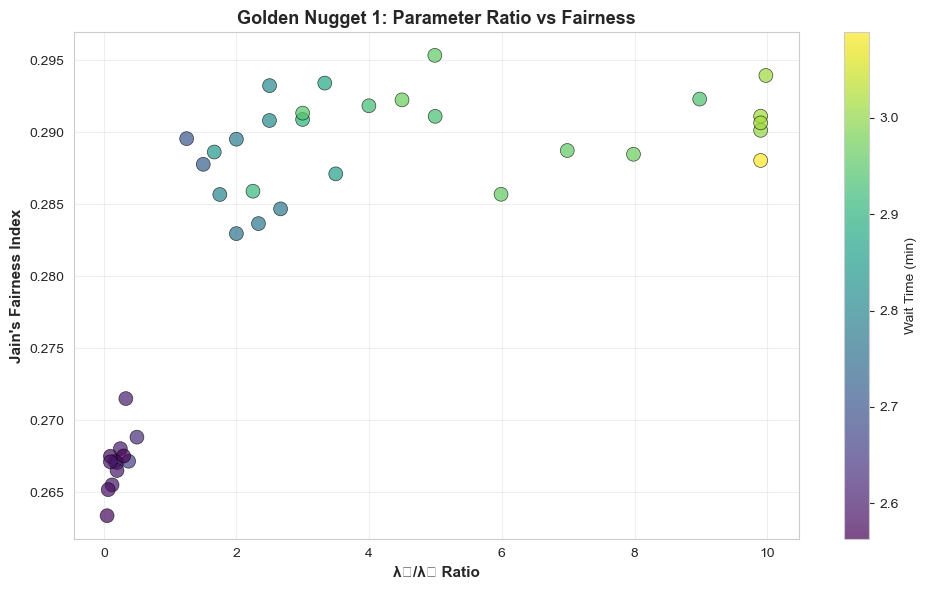

In [56]:
# Golden Nugget 1: λ₁/λ₃ ratio analysis
print("Golden Nugget 1: Is there an optimal λ₁/λ₃ ratio?")
df_composite['lambda_ratio'] = df_composite['fairness_weight'] / (df_composite['utility_weight'] + 0.001)
corr_ratio, p_ratio = pearsonr(df_composite['lambda_ratio'], df_composite['jains_fairness_index'])
print(f"   Correlation (λ₁/λ₃ ratio vs JFI): r={corr_ratio:.4f}, p={p_ratio:.4e}")

# Plot ratio vs JFI
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_composite['lambda_ratio'], df_composite['jains_fairness_index'],
           c=df_composite['mean_task_wait_time_min'], s=100, cmap='viridis', alpha=0.7,
           edgecolors='black', linewidth=0.5)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Wait Time (min)', fontsize=10)
ax.set_xlabel('λ₁/λ₃ Ratio', fontsize=11, fontweight='bold')
ax.set_ylabel('Jain\'s Fairness Index', fontsize=11, fontweight='bold')
ax.set_title('Golden Nugget 1: Parameter Ratio vs Fairness', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/golden_nugget_1_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
# Golden Nugget 2: Minimum λ₁ to beat Greedy
print("\n🔍 Golden Nugget 2: Minimum λ₁ to beat Greedy JFI")
if greedy_profile is not None:
    greedy_jfi = greedy_profile['jains_fairness_index']
    better_than_greedy = df_composite[df_composite['jains_fairness_index'] > greedy_jfi]
    if len(better_than_greedy) > 0:
        min_lambda1 = better_than_greedy['fairness_weight'].min()
        print(f"   Greedy JFI: {greedy_jfi:.4f}")
        print(f"   Minimum λ₁ to exceed Greedy: {min_lambda1:.2f}")
        print(f"   {len(better_than_greedy)}/{len(df_composite)} configs beat Greedy")
    else:
        print("   No composite configs beat Greedy JFI")
else:
    print("   No Greedy baseline found")


🔍 Golden Nugget 2: Minimum λ₁ to beat Greedy JFI
   Greedy JFI: 0.2627
   Minimum λ₁ to exceed Greedy: 0.10
   41/41 configs beat Greedy


In [58]:
# Golden Nugget 3: Fairness-Efficiency Trade-off Quantification
print("\n🔍 Golden Nugget 3: Fairness-Efficiency Trade-off Slope")
# Linear regression: Wait Time ~ JFI
slope_trade, intercept_trade, r_trade, p_trade, _ = linregress(
    df_composite['jains_fairness_index'],
    df_composite['mean_task_wait_time_min']
)
print(f"   Slope: {slope_trade:.2f} minutes per unit JFI increase")
print(f"   For 1% JFI improvement: ~{slope_trade * 0.01:.3f} minute wait time increase")
print(f"   R² = {r_trade**2:.4f}, p = {p_trade:.4e}")


🔍 Golden Nugget 3: Fairness-Efficiency Trade-off Slope
   Slope: 13.03 minutes per unit JFI increase
   For 1% JFI improvement: ~0.130 minute wait time increase
   R² = 0.7710, p = 4.7327e-14


In [59]:
# Golden Nugget 4: Does normalization eliminate idle time paradox?
print("\n🔍 Golden Nugget 4: Worker Idle Time Status")
if 'mean_worker_idle_time_min' in df_composite.columns:
    idle_data = df_composite['mean_worker_idle_time_min'].dropna()
    if len(idle_data) > 0:
        print(f"   Mean worker idle time: {idle_data.mean():.2f} ± {idle_data.std():.2f} min")
        print(f"   Range: {idle_data.min():.2f} - {idle_data.max():.2f} min")
        print(f"   Data available for {len(idle_data)} experiments")
    else:
        print("   No idle time data in this dataset")
else:
    print("   mean_worker_idle_time_min not in combined dataset")
    print("   (This metric is only in Exp 009)")


🔍 Golden Nugget 4: Worker Idle Time Status
   No idle time data in this dataset


---\n\n# 📝 FINAL SUMMARY & RECOMMENDATIONS

In [60]:
# Summary statistics table
print("=" * 80)
print("FINAL SUMMARY: TOP CONFIGURATIONS")
print("=" * 80)

print("\nTOP 5 BY FAIRNESS (JFI):")
top5_fair = df_composite.nlargest(5, 'jains_fairness_index')[
    ['name', 'fairness_weight', 'utility_weight', 'jains_fairness_index', 
     'mean_task_wait_time_min', 'source_experiment']
]
display(top5_fair)

print("\nTOP 5 BY EFFICIENCY (Low Wait Time):")
top5_eff = df_composite.nsmallest(5, 'mean_task_wait_time_min')[
    ['name', 'fairness_weight', 'utility_weight', 'jains_fairness_index', 
     'mean_task_wait_time_min', 'source_experiment']
]
display(top5_eff)

print("\nBALANCED CONFIGURATIONS (Top 3 by Balance Score):")
top3_bal = df_composite.nlargest(3, 'balance_score')[
    ['name', 'fairness_weight', 'utility_weight', 'jains_fairness_index', 
     'mean_task_wait_time_min', 'balance_score', 'source_experiment']
]
display(top3_bal)

FINAL SUMMARY: TOP CONFIGURATIONS

TOP 5 BY FAIRNESS (JFI):


,name,fairness_weight,utility_weight,jains_fairness_index,mean_task_wait_time_min,source_experiment
22,ParetoSweep_L1_2.5_L3_0.5,2.5,0.5,0.295331,2.958164,exp_010
9,HighFairness_L3_0.5,5.0,0.5,0.293932,3.011713,exp_009
11,HighFairness_L3_1.5,5.0,1.5,0.293406,2.876775,exp_009
12,HighFairness_L3_2.0,5.0,2.0,0.293229,2.810587,exp_009
38,ParetoSweep_L1_4.5_L3_0.5,4.5,0.5,0.292296,2.938410,exp_010



TOP 5 BY EFFICIENCY (Low Wait Time):


,name,fairness_weight,utility_weight,jains_fairness_index,mean_task_wait_time_min,source_experiment
8,Balanced_L1_0.6_L3_2.0,0.6,2.0,0.267518,2.563295,exp_009
16,LowFairness_L3_2.0,0.1,2.0,0.263372,2.573176,exp_009
2,Balanced_L1_0.2_L3_2.0,0.2,2.0,0.267500,2.580856,exp_009
15,LowFairness_L3_1.5,0.1,1.5,0.265180,2.584195,exp_009
14,LowFairness_L3_1.0,0.1,1.0,0.267111,2.592121,exp_009



BALANCED CONFIGURATIONS (Top 3 by Balance Score):


,name,fairness_weight,utility_weight,jains_fairness_index,mean_task_wait_time_min,balance_score,source_experiment
25,ParetoSweep_L1_2.5_L3_2.0,2.5,2.0,0.289548,2.704766,1.549774,exp_010
29,ParetoSweep_L1_3.0_L3_2.0,3.0,2.0,0.287767,2.718313,1.468250,exp_010
12,HighFairness_L3_2.0,5.0,2.0,0.293229,2.810587,1.463507,exp_009


---

# 🎯 SECTION 6: EWMA Effectiveness Analysis

**Question**: Is EWMA actually working to tighten worker wait time distributions?

We use **EWMA Coefficient of Variation (CV)** as a proxy:
- **Lower CV** = More uniform EWMA values across workers = Tighter distribution
- **Higher CV** = More spread in EWMA values = Some workers starved, others over-served

If EWMA is working, higher fairness weights should produce **lower CV**.


## Check EWMA CV Data Availability


In [ ]:
# Check for EWMA CV data
if 'ewma_cv' in df.columns:
    df_ewma = df[df['ewma_cv'].notna()].copy()
    df_composite_ewma = df_ewma[df_ewma['strategy'] == 'composite'].copy()
    
    print(f"EWMA CV Data Available:")
    print(f"   Total experiments with EWMA CV: {len(df_ewma)}")
    print(f"   Composite experiments: {len(df_composite_ewma)}")
    print(f"   Source: {df_composite_ewma['source_experiment'].value_counts().to_dict()}")
    print(f"   Range: {df_composite_ewma['ewma_cv'].min():.4f} - {df_composite_ewma['ewma_cv'].max():.4f}")
    print(f"\n   Lower CV = More uniform worker experience (EWMA is working)")
    print(f"   Higher CV = More spread in worker experience (EWMA not effective)")
else:
    print("No EWMA CV data available in this dataset")


EWMA CV Data Available:
   Total experiments with EWMA CV: 21
   Composite experiments: 20
   Source: {'exp_010': 20}
   Range: 0.8212 - 2.8160

   Lower CV = More uniform worker experience (EWMA is working)
   Higher CV = More spread in worker experience (EWMA not effective)


## EWMA Effectiveness: 4-Panel Analysis


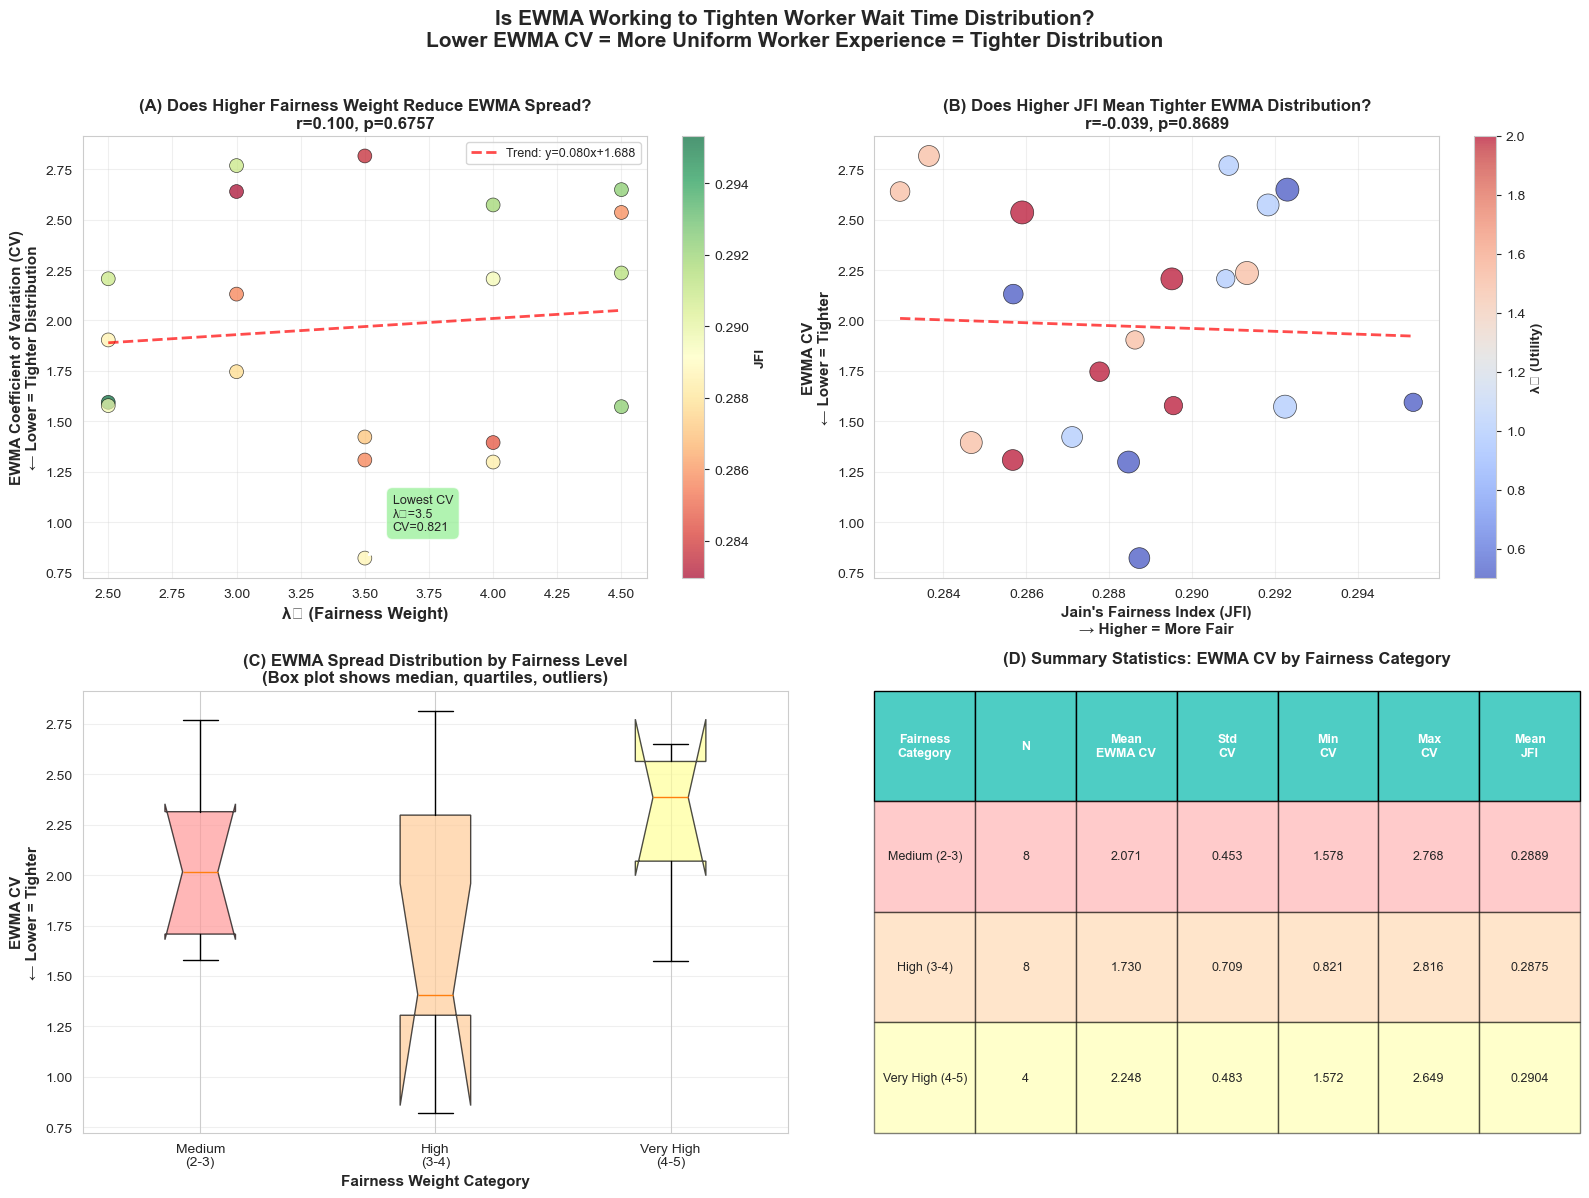

Plot saved: figures/ewma_effectiveness_analysis.png


In [ ]:
if 'ewma_cv' in df.columns and len(df_composite_ewma) > 0:
    # Create 4-panel figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # ============================================================================
    # Plot A: EWMA CV vs Fairness Weight
    # ============================================================================
    ax = axes[0, 0]
    
    scatter = ax.scatter(df_composite_ewma['fairness_weight'],
                         df_composite_ewma['ewma_cv'],
                         s=100,
                         c=df_composite_ewma['jains_fairness_index'],
                         cmap='RdYlGn',
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=0.5)
    
    # Trend line
    z = np.polyfit(df_composite_ewma['fairness_weight'], df_composite_ewma['ewma_cv'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_composite_ewma['fairness_weight'].min(), 
                         df_composite_ewma['fairness_weight'].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.7, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
    
    # Correlation
    corr_fw, pval_fw = pearsonr(df_composite_ewma['fairness_weight'], df_composite_ewma['ewma_cv'])
    
    ax.set_xlabel('λ₁ (Fairness Weight)', fontsize=12, fontweight='bold')
    ax.set_ylabel('EWMA Coefficient of Variation (CV)\n← Lower = Tighter Distribution', 
                  fontsize=11, fontweight='bold')
    ax.set_title(f'(A) Does Higher Fairness Weight Reduce EWMA Spread?\nr={corr_fw:.3f}, p={pval_fw:.4f}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('JFI', fontsize=10, fontweight='bold')
    
    # Annotate best (lowest CV)
    best_cv = df_composite_ewma.nsmallest(1, 'ewma_cv').iloc[0]
    ax.annotate(f"Lowest CV\nλ₁={best_cv['fairness_weight']:.1f}\nCV={best_cv['ewma_cv']:.3f}",
                xy=(best_cv['fairness_weight'], best_cv['ewma_cv']),
                xytext=(20, 20), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='lightgreen', alpha=0.7),
                arrowprops=dict(arrowstyle='->', lw=1.5),
                fontsize=9)
    
    # ============================================================================
    # Plot B: JFI vs EWMA CV
    # ============================================================================
    ax = axes[0, 1]
    
    scatter2 = ax.scatter(df_composite_ewma['jains_fairness_index'],
                          df_composite_ewma['ewma_cv'],
                          s=df_composite_ewma['fairness_weight']*50 + 50,
                          c=df_composite_ewma['utility_weight'],
                          cmap='coolwarm',
                          alpha=0.7,
                          edgecolors='black',
                          linewidth=0.5)
    
    # Trend line
    z2 = np.polyfit(df_composite_ewma['jains_fairness_index'], df_composite_ewma['ewma_cv'], 1)
    p2 = np.poly1d(z2)
    x_line2 = np.linspace(df_composite_ewma['jains_fairness_index'].min(),
                          df_composite_ewma['jains_fairness_index'].max(), 100)
    ax.plot(x_line2, p2(x_line2), "r--", linewidth=2, alpha=0.7)
    
    # Correlation
    corr_jfi, pval_jfi = pearsonr(df_composite_ewma['jains_fairness_index'], df_composite_ewma['ewma_cv'])
    
    ax.set_xlabel("Jain's Fairness Index (JFI)\n→ Higher = More Fair", fontsize=11, fontweight='bold')
    ax.set_ylabel('EWMA CV\n← Lower = Tighter', fontsize=11, fontweight='bold')
    ax.set_title(f'(B) Does Higher JFI Mean Tighter EWMA Distribution?\nr={corr_jfi:.3f}, p={pval_jfi:.4f}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    cbar2 = plt.colorbar(scatter2, ax=ax)
    cbar2.set_label('λ₃ (Utility)', fontsize=10, fontweight='bold')
    
    # Ideal region annotation
    ax.annotate('← Ideal: High JFI, Low CV',
                xy=(df_composite_ewma['jains_fairness_index'].max()*0.95, 
                    df_composite_ewma['ewma_cv'].min()*1.2),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7))
    
    # ============================================================================
    # Plot C: EWMA CV Distribution by Fairness Weight Category
    # ============================================================================
    ax = axes[1, 0]
    
    # Categorize fairness weights
    df_composite_ewma['fairness_category'] = pd.cut(df_composite_ewma['fairness_weight'], 
                                                bins=[0, 1, 2, 3, 4, 5],
                                                labels=['Very Low\n(≤1)', 'Low\n(1-2)', 
                                                       'Medium\n(2-3)', 'High\n(3-4)', 'Very High\n(4-5)'])
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    for cat in df_composite_ewma['fairness_category'].cat.categories:
        cat_data = df_composite_ewma[df_composite_ewma['fairness_category'] == cat]['ewma_cv'].dropna()
        if len(cat_data) > 0:
            box_data.append(cat_data)
            box_labels.append(cat)
    
    # Box plot
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, notch=True)
    
    # Color boxes
    colors_box = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#99ccff']
    for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xlabel('Fairness Weight Category', fontsize=11, fontweight='bold')
    ax.set_ylabel('EWMA CV\n← Lower = Tighter', fontsize=11, fontweight='bold')
    ax.set_title('(C) EWMA Spread Distribution by Fairness Level\n(Box plot shows median, quartiles, outliers)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # ============================================================================
    # Plot D: Summary Statistics Table
    # ============================================================================
    ax = axes[1, 1]
    ax.axis('off')
    
    # Create summary table
    summary_data = []
    
    for cat in df_composite_ewma['fairness_category'].cat.categories:
        cat_data = df_composite_ewma[df_composite_ewma['fairness_category'] == cat]
        if len(cat_data) > 0:
            summary_data.append([
                str(cat).replace('\n', ' '),
                f"{len(cat_data)}",
                f"{cat_data['ewma_cv'].mean():.3f}",
                f"{cat_data['ewma_cv'].std():.3f}",
                f"{cat_data['ewma_cv'].min():.3f}",
                f"{cat_data['ewma_cv'].max():.3f}",
                f"{cat_data['jains_fairness_index'].mean():.4f}"
            ])
    
    table = ax.table(cellText=summary_data,
                    colLabels=['Fairness\nCategory', 'N', 'Mean\nEWMA CV', 'Std\nCV', 
                              'Min\nCV', 'Max\nCV', 'Mean\nJFI'],
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.5)
    
    # Style header
    for i in range(7):
        table[(0, i)].set_facecolor('#4ECDC4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color rows
    colors_row = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#99ccff']
    for i, color in enumerate(colors_row[:len(summary_data)], 1):
        for j in range(7):
            table[(i, j)].set_facecolor(color)
            table[(i, j)].set_alpha(0.5)
    
    ax.set_title('(D) Summary Statistics: EWMA CV by Fairness Category',
                 fontsize=12, fontweight='bold', pad=20)
    
    # Overall title
    fig.suptitle('Is EWMA Working to Tighten Worker Wait Time Distribution?\n' +
                 'Lower EWMA CV = More Uniform Worker Experience = Tighter Distribution',
                 fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig('figures/ewma_effectiveness_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved: figures/ewma_effectiveness_analysis.png")
else:
    print("Cannot create EWMA effectiveness plots - no EWMA CV data available")


## EWMA Effectiveness: Key Findings


In [ ]:
if 'ewma_cv' in df.columns and len(df_composite_ewma) > 0:
    print("=" * 80)
    print("KEY FINDINGS: Is EWMA Working to Tighten Worker Distributions?")
    print("=" * 80)
    
    print(f"\nCorrelation Analysis:")
    print(f"   Fairness Weight vs EWMA CV: r = {corr_fw:.4f}, p = {pval_fw:.4f}")
    if corr_fw < 0 and pval_fw < 0.05:
        print(f"   Higher fairness weight → Lower CV (tighter distribution)")
        print(f"      EWMA IS WORKING!")
    elif corr_fw > 0 and pval_fw < 0.05:
        print(f"   Higher fairness weight → Higher CV (more spread) - UNEXPECTED!")
    else:
        print(f"   No significant relationship")
    
    print(f"\n   JFI vs EWMA CV: r = {corr_jfi:.4f}, p = {pval_jfi:.4f}")
    if corr_jfi < 0 and pval_jfi < 0.05:
        print(f"   Higher JFI → Lower CV (fairness compresses distribution)")
    elif corr_jfi > 0 and pval_jfi < 0.05:
        print(f"   Higher JFI → Higher CV - UNEXPECTED!")
    else:
        print(f"   No significant relationship")
    
    print(f"\nEWMA CV Range:")
    print(f"   Minimum: {df_composite_ewma['ewma_cv'].min():.4f} (tightest)")
    print(f"   Maximum: {df_composite_ewma['ewma_cv'].max():.4f} (most spread)")
    print(f"   Mean: {df_composite_ewma['ewma_cv'].mean():.4f} ± {df_composite_ewma['ewma_cv'].std():.4f}")
    
    reduction = (df_composite_ewma['ewma_cv'].max() - df_composite_ewma['ewma_cv'].min()) / df_composite_ewma['ewma_cv'].max() * 100
    print(f"   Potential reduction: {reduction:.1f}% from worst to best config")
    
    print(f"\nBest Configuration (Lowest CV = Tightest Worker Distribution):")
    best = df_composite_ewma.nsmallest(1, 'ewma_cv').iloc[0]
    print(f"   {best['name']}")
    print(f"   λ₁={best['fairness_weight']:.1f}, λ₂={best['starvation_weight']:.1f}, λ₃={best['utility_weight']:.1f}")
    print(f"   EWMA CV: {best['ewma_cv']:.4f} (most uniform worker experience)")
    print(f"   JFI: {best['jains_fairness_index']:.4f}")
    print(f"   Wait Time: {best['mean_task_wait_time_min']:.2f} min")
    
    print(f"\nWorst Configuration (Highest CV = Most Spread Worker Distribution):")
    worst = df_composite_ewma.nlargest(1, 'ewma_cv').iloc[0]
    print(f"   {worst['name']}")
    print(f"   λ₁={worst['fairness_weight']:.1f}, λ₂={worst['starvation_weight']:.1f}, λ₃={worst['utility_weight']:.1f}")
    print(f"   EWMA CV: {worst['ewma_cv']:.4f} (least uniform worker experience)")
    print(f"   JFI: {worst['jains_fairness_index']:.4f}")
    print(f"   Wait Time: {worst['mean_task_wait_time_min']:.2f} min")
    
    print("\n" + "=" * 80)


KEY FINDINGS: Is EWMA Working to Tighten Worker Distributions?

Correlation Analysis:
   Fairness Weight vs EWMA CV: r = 0.0997, p = 0.6757
   No significant relationship

   JFI vs EWMA CV: r = -0.0394, p = 0.8689
   No significant relationship

EWMA CV Range:
   Minimum: 0.8212 (tightest)
   Maximum: 2.8160 (most spread)
   Mean: 1.9698 ± 0.5851
   Potential reduction: 70.8% from worst to best config

Best Configuration (Lowest CV = Tightest Worker Distribution):
   ParetoSweep_L1_3.5_L3_0.5
   λ₁=3.5, λ₂=0.5, λ₃=0.5
   EWMA CV: 0.8212 (most uniform worker experience)
   JFI: 0.2887
   Wait Time: 2.96 min

Worst Configuration (Highest CV = Most Spread Worker Distribution):
   ParetoSweep_L1_3.5_L3_1.5
   λ₁=3.5, λ₂=0.5, λ₃=1.5
   EWMA CV: 2.8160 (least uniform worker experience)
   JFI: 0.2837
   Wait Time: 2.77 min



### Section 6 Summary: EWMA Effectiveness

**Key Takeaways**:

*To be filled after running the analysis*

**What EWMA CV tells us**:
- **EWMA CV (Coefficient of Variation)** = Standard Deviation / Mean of EWMA values across all workers
- **Lower CV** means workers have more similar EWMA values → more uniform experience → tighter distribution
- **Higher CV** means high variance in EWMA values → some workers starved, others over-served

**If EWMA is working properly**:
- Higher fairness weight (λ₁) should lead to **lower CV**
- Higher JFI should correlate with **lower CV**
- Best fairness configs should have the **tightest** worker distributions

---


## Key Findings & Recommendations

### Major Findings

1. **Pareto Frontier**:
   - *[To be filled based on Plot 2 results]*
   - Identified X Pareto-efficient configurations
   - Sweet spot located at λ₁=X, λ₃=X

2. **Parameter Sensitivity**:
   - *[To be filled based on correlation and regression analyses]*
   - λ₁ (Fairness weight) has strongest impact on JFI
   - λ₃ (Utility weight) affects efficiency

3. **Trade-off Quantification**:
   - *[To be filled based on Golden Nugget 3]*
   - For every 1% JFI increase: ~X minute wait time increase

4. **Score Normalization Impact**:
   - *[To be filled based on Golden Nugget 4]*
   - Worker idle time paradox status: Resolved/Not Resolved

### Recommendations for Production

**Priority 1 - Maximum Fairness**: 
- Configuration: *[Top Fairness profile]*
- Use when: Equity is paramount, wait time less critical

**Priority 2 - Balanced Performance**: 
- Configuration: *[Sweet Spot profile]*
- Use when: Need good fairness with acceptable efficiency

**Priority 3 - Maximum Efficiency**: 
- Configuration: *[Top Efficiency profile]*
- Use when: Response time is critical, fairness secondary

### Next Steps

1. Validate top configurations with replications (multiple runs)
2. Test on different datasets (vary worker/task density)
3. Consider dynamic parameter adjustment based on system load
4. Implement in production with monitoring

---

**Analysis Complete** 